# Task 1: Article-Type Classification

COSC2753 | Machine Learning

> **Historical training run:** the outputs below precede the lighting/confidence follow-up. Active checkpoints now include that follow-up. Re-running these training/export cells overwrites them. See the final appendix and [CLASSIFIER_IMPROVEMENTS.md](../CLASSIFIER_IMPROVEMENTS.md).

## 1. Introduction

This follow-up experiment compares a majority reference, HOG + HSV logistic
regression, and one plain three-block CNN per target. The goal is a model that is
effective and easy to explain. All models are trained from scratch on the
supplied training rows. The frozen group split and training-only normalization
are preserved. Literal `NA` remains a usage label.

The same CNN settings are used for every target: ordinary cross-entropy, Adam
at 0.001, batch size 64, at most 30 epochs, patience 5 and horizontal flips only.
Select on validation macro F1; within 0.01, prefer lower validation ECE, then
parameter count. The majority reference cannot win.

Earlier test results have already been seen. This is explicitly a follow-up
after test exposure, not a fresh untouched holdout. No follow-up test scores are
used to tune or select models. See [the simplification record](../docs/SIMPLIFICATION_EXPERIMENT.md).

## 2. Library Imports and Setup

In [1]:
from pathlib import Path
import json, sys, time

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'scripts'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, top_k_accuracy_score)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import torch

from app.server.utils.modeling import SimpleCNN
from scripts.classification import make_loader, train_cnn, predict_cnn, comparison_row
from app.server.utils.classifier import FashionClassifier
from app.server.utils.handcrafted import DEFAULT_FEATURE_CONFIG, handcrafted_feature
from evaluation import calibration_table, expected_calibration_error, high_confidence_errors, ordered_estimator_probabilities, saved_model_robustness, select_validation_candidate
from preprocessing import IMAGE_SIZE, NORMALISATION_PATH, SEED, seed_everything, select_torch_device, task_frame

seed_everything(SEED)
torch.manual_seed(SEED)
DEVICE = select_torch_device()
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
DEVICE


Using CUDA: NVIDIA GeForce RTX 3060 | PyTorch 2.11.0+cu128 | CUDA 12.8


device(type='cuda')

## 3. Load the Frozen Data

In [2]:
TARGET = 'articleType'
train_df = task_frame(TARGET, 'train')
validation_df = task_frame(TARGET, 'validation')
test_df = task_frame(TARGET, 'test')
with NORMALISATION_PATH.open(encoding='utf-8') as handle:
    normalisation = json.load(handle)
labels = sorted(train_df[TARGET].unique())
label_to_index = {label: index for index, label in enumerate(labels)}
def supported_macro_f1(truth, predictions):
    return f1_score(truth, predictions, labels=np.unique(truth), average='macro', zero_division=0)
len(train_df), len(validation_df), len(test_df), len(labels)

(27051, 5842, 5718, 124)

## 4. Target-Specific EDA

count     124.000000
mean      218.153226
std       553.542575
min         1.000000
25%         6.000000
50%        30.500000
75%       168.250000
max      4759.000000
Name: count, dtype: float64

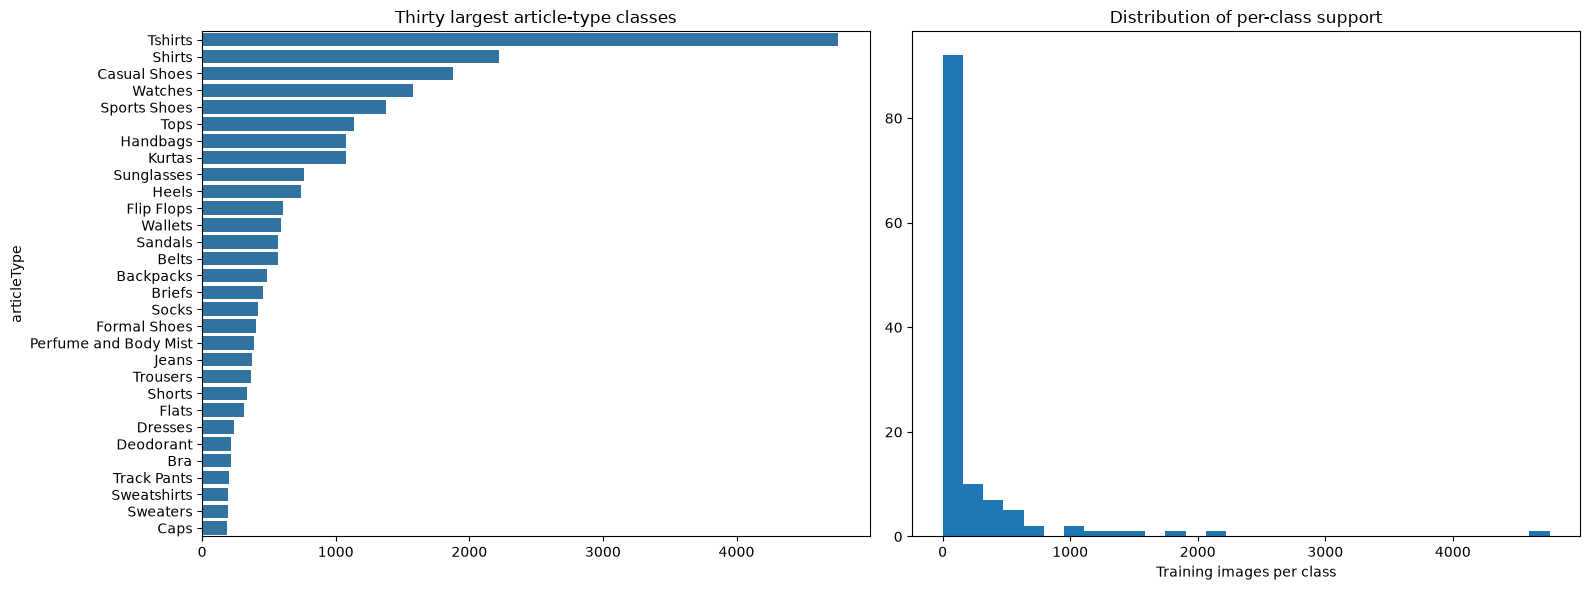

In [3]:
counts = train_df[TARGET].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=counts.head(30).values, y=counts.head(30).index, ax=axes[0])
axes[0].set_title('Thirty largest article-type classes')
axes[1].hist(counts.values, bins=30)
axes[1].set_title('Distribution of per-class support')
axes[1].set_xlabel('Training images per class')
plt.tight_layout()
counts.describe()

### 4.1 Observations

The frozen training split contains 27,051 images across 124 article types. Training support defines tail (<50), medium (50–499), and head (at least 500) classes. There are 72 classes below 50 examples, including 42 below 10; the largest class has 4,759 images and the smallest has one. The checks below find no validation-only or test-only labels. Training-label coverage does not guarantee adequate test support: 23 training labels are absent from the internal test partition and are excluded from its supported-label macro F1.

The current question is whether a plain CNN can provide an effective, simpler alternative to balanced HOG+HSV logistic regression. The earlier effective-number weighting experiment is historical; it is not run in this notebook. Architecture and training settings changed together, so this comparison cannot isolate the effect of any single change. Bags, footwear and related garment labels are plausible confusion families; the measured errors below assess them without treating similarity as proof of a causal failure mechanism.

In [4]:
{
    'validation_only': sorted(set(validation_df[TARGET]) - set(labels)),
    'test_only': sorted(set(test_df[TARGET]) - set(labels)),
    'classes_below_10': int((counts < 10).sum()),
    'classes_below_50': int((counts < 50).sum()),
}

{'validation_only': [],
 'test_only': [],
 'classes_below_10': 42,
 'classes_below_50': 72}

## 5. Majority Baseline

In [5]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(np.zeros((len(train_df), 1)), train_df[TARGET])
dummy_predictions = dummy.predict(np.zeros((len(validation_df), 1)))
dummy_probabilities = ordered_estimator_probabilities(dummy, np.zeros((len(validation_df), 1)), labels)
majority_metrics = {
    'accuracy': accuracy_score(validation_df[TARGET], dummy_predictions),
    'macro_f1': supported_macro_f1(validation_df[TARGET], dummy_predictions),
}
majority_metrics

{'accuracy': 0.17750770284149264, 'macro_f1': 0.0028990126024578703}

## 6. HOG + HSV Classical Baseline

HOG represents garment shape while HSV histograms represent colour. The class-weighted linear model tests how far transparent handcrafted features can go before deep learning.

In [6]:
def handcrafted_feature_path(path):
    with Image.open(path) as source:
        return handcrafted_feature(source, DEFAULT_FEATURE_CONFIG)

def feature_matrix(frame):
    return np.vstack([handcrafted_feature_path(path) for path in frame.image_path])

train_features = feature_matrix(train_df)
validation_features = feature_matrix(validation_df)
linear_baseline = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs'),
)
linear_baseline.fit(train_features, train_df[TARGET])
linear_predictions = linear_baseline.predict(validation_features)
linear_probabilities = ordered_estimator_probabilities(linear_baseline, validation_features, labels)
linear_metrics = {
    'accuracy': accuracy_score(validation_df[TARGET], linear_predictions),
    'macro_f1': supported_macro_f1(validation_df[TARGET], linear_predictions),
}
linear_metrics

{'accuracy': 0.7887709688462855, 'macro_f1': 0.6096283006006169}

## 7. Image pipeline

Resize and normalize every image. Only training images receive random horizontal flips. The dataset and loaders are defined in [classification.py](../scripts/classification.py).

In [7]:
train_loader = make_loader(train_df, TARGET, labels, normalisation, training=True)
validation_loader = make_loader(validation_df, TARGET, labels, normalisation)
test_loader = make_loader(test_df, TARGET, labels, normalisation)


## 8. Plain CNN architecture

| Stage | Operation | Purpose |
|---|---|---|
| Input | RGB, 128 high x 96 wide; frozen training normalization | Consistent input |
| Block 1 | Conv 3x3, 32 channels -> BatchNorm -> ReLU -> MaxPool 2x2 | Local edges |
| Block 2 | Conv 3x3, 64 channels -> BatchNorm -> ReLU -> MaxPool 2x2 | Combine patterns |
| Block 3 | Conv 3x3, 128 channels -> BatchNorm -> ReLU -> MaxPool 2x2 | Higher-level features |
| Head | Adaptive average pool 2x2 -> Flatten -> Dense 128 -> ReLU -> Dropout 0.2 -> output | Predict target logits |

There are no residual connections or pretrained weights. The single definition
in [modeling.py](../app/server/utils/modeling.py) is shared with API inference.
The table describes the intended roles; it is not evidence of what each filter learned.

In [8]:
example_model = SimpleCNN(len(labels))
print(example_model)
print('Parameters:', sum(p.numel() for p in example_model.parameters()))


SimpleCNN(
  (layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(2, 2))
    (13): Flatten(start_dim=1, end_dim=-1)
    (14): Linear(in_features=512, out_features=128, bias=True)
    (15): ReLU()

## 9. Train one CNN

The short shared [training loop](../scripts/classification.py) performs the same
steps each epoch: predict, compute ordinary cross-entropy, backpropagate and update
with Adam; then evaluate without gradients. Save the state whenever validation
macro F1 improves and stop after five non-improving epochs (30 maximum).
There is no loss-mode search, scheduler or per-target hyperparameter tuning.
Training F1 uses augmented images and training-mode layers, so its gap from
validation F1 is descriptive rather than an identical-conditions comparison.

Epoch 01: train F1=0.0732, validation F1=0.1480, 134.2s


Epoch 02: train F1=0.1550, validation F1=0.1827, 190.0s


Epoch 03: train F1=0.2057, validation F1=0.2240, 125.3s


Epoch 04: train F1=0.2400, validation F1=0.2485, 174.3s


Epoch 05: train F1=0.2786, validation F1=0.2666, 34.5s


...

Epoch 26: train F1=0.5857, validation F1=0.5280, 26.9s


Epoch 27: train F1=0.6019, validation F1=0.5001, 27.8s


Epoch 28: train F1=0.6006, validation F1=0.5203, 27.8s


Epoch 29: train F1=0.5911, validation F1=0.5219, 27.8s


Epoch 30: train F1=0.6006, validation F1=0.5347, 25.6s


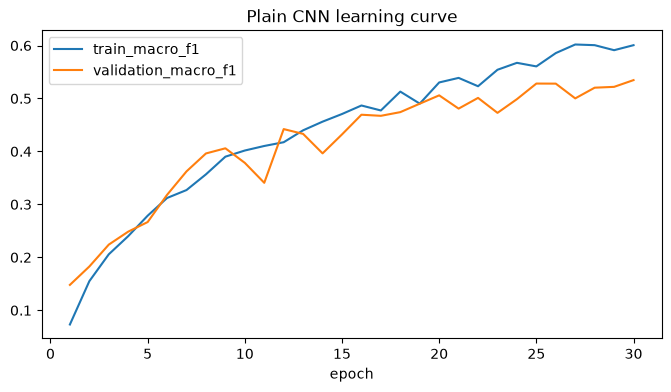

In [9]:
seed_everything(SEED)
torch.manual_seed(SEED)
cnn_model = SimpleCNN(len(labels))
cnn_model, cnn_history = train_cnn(
    cnn_model, train_loader, validation_loader, DEVICE,
    max_epochs=30, patience=5,
)
cnn_history.plot(x='epoch', y=['train_macro_f1', 'validation_macro_f1'],
                 title='Plain CNN learning curve', figsize=(8, 4))
plt.show()


In [10]:
validation_truth = np.asarray([label_to_index[label] for label in validation_df[TARGET]])
cnn_probabilities = predict_cnn(cnn_model, validation_loader, DEVICE)
linear_parameters = linear_baseline[-1].coef_.size + linear_baseline[-1].intercept_.size
cnn_parameters = sum(parameter.numel() for parameter in cnn_model.parameters())
comparison = pd.DataFrame([
    comparison_row('majority', 'reference_only', validation_truth,
                   dummy_probabilities, 1, eligible=False),
    comparison_row('hog_hsv_logistic_regression', 'hog_hsv_logistic_regression',
                   validation_truth, linear_probabilities, linear_parameters),
    comparison_row('cnn_ordinary', 'simple_cnn', validation_truth,
                   cnn_probabilities, cnn_parameters, epochs=len(cnn_history)),
]).set_index('method')
display(comparison)
SELECTED_METHOD = select_validation_candidate(comparison.loc[comparison.eligible_for_selection])
SELECTED_MODEL_TYPE = comparison.loc[SELECTED_METHOD, 'model_type']
best_f1 = float(comparison.loc[SELECTED_METHOD, 'validation_macro_f1'])
if SELECTED_MODEL_TYPE == 'simple_cnn':
    SELECTED_LOSS_MODE = 'ordinary'
    model = cnn_model
    history = cnn_history
else:
    SELECTED_LOSS_MODE = None
    model = linear_baseline
    history = pd.DataFrame([{'method': SELECTED_METHOD, **comparison.loc[SELECTED_METHOD].to_dict()}])
print(f'Selected {SELECTED_METHOD!r} before follow-up test evaluation.')

cnn_history.to_csv(ROOT / 'models' / 'article_type_cnn_history.csv', index=False)


,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection
method,,,,,,,
majority,reference_only,0.177508,0.002899,0.822492,1,0,False
hog_hsv_logistic_regression,hog_hsv_logistic_regression,0.788771,0.609628,0.117779,159340,0,True
cnn_ordinary,simple_cnn,0.824546,0.534652,0.013472,175356,30,True


Selected 'hog_hsv_logistic_regression' before follow-up test evaluation.


In [11]:
if 'epoch' in history.columns:
    history.plot(x='epoch', y=['train_macro_f1', 'validation_macro_f1'], figsize=(8, 4), title='Article-type learning curve')
    plt.show()
else:
    display(history)

,method,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection
0,hog_hsv_logistic_regression,hog_hsv_logistic_regression,0.788771,0.609628,0.117779,159340,0,True


### 9.1 Training and selection analysis

Validation macro F1: majority 0.0029, HOG+HSV 0.6096, plain CNN 0.5347. The predeclared selection rule chooses **hog_hsv_logistic_regression** (validation ECE 0.1178).

The CNN's best epoch is 30; it runs for 30 epochs. At that epoch training/validation macro F1 are 0.6006/0.5347, a gap of 0.0660. Training uses flips, dropout and batch statistics, so these are different evaluation conditions. The full CNN history is retained even when the classical model wins.

## 10. Follow-up internal-test evaluation

Method and hyperparameters are frozen before this section. This is a disclosed follow-up after earlier test exposure.

In [12]:
test_truth = np.asarray([label_to_index[label] for label in test_df[TARGET]])
if SELECTED_MODEL_TYPE == 'simple_cnn':
    test_probabilities = predict_cnn(model, test_loader, DEVICE)
else:
    test_features = feature_matrix(test_df)
    test_probabilities = ordered_estimator_probabilities(model, test_features, labels)
test_predictions = test_probabilities.argmax(1)
test_metrics = {
    'accuracy': accuracy_score(test_truth, test_predictions),
    'ece': expected_calibration_error(test_truth, test_probabilities),
    'macro_f1': supported_macro_f1(test_truth, test_predictions),
    'top_3_accuracy': top_k_accuracy_score(test_truth, test_probabilities, k=3, labels=np.arange(len(labels))),
}
display(test_metrics)
display(calibration_table(test_truth, test_probabilities))
display(high_confidence_errors(test_df, TARGET, labels, test_truth, test_predictions, test_probabilities))
from evaluation import support_band_metrics
display(support_band_metrics(
    np.asarray(labels)[test_truth], np.asarray(labels)[test_predictions],
    train_df[TARGET].value_counts(),
))


{'accuracy': 0.7782441413081497,
 'ece': 0.1221406766639885,
 'macro_f1': 0.6113939573028555,
 'top_3_accuracy': 0.9419377404686954}

,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",NaN,NaN,0
"(0.2, 0.3]",0.286943,0.000000,3
"(0.3, 0.4]",0.357864,0.157895,57
"(0.4, 0.5]",0.457847,0.247863,117
"(0.5, 0.6]",0.549969,0.431677,322
"(0.6, 0.7]",0.651718,0.509934,302
"(0.7, 0.8]",0.751319,0.549296,355
"(0.8, 0.9]",0.854046,0.623218,491


,id,articleType,image_path,truth,prediction,confidence
3564,30881,Kurtis,D:\khoile\programs\fashion-intelligence-classi...,Kurtis,Kurtas,1.000000
3229,28105,Boxers,D:\khoile\programs\fashion-intelligence-classi...,Boxers,Trunk,0.999994
4846,42844,Handbags,D:\khoile\programs\fashion-intelligence-classi...,Handbags,Laptop Bag,0.999994
3391,29461,Free Gifts,D:\khoile\programs\fashion-intelligence-classi...,Free Gifts,Watches,0.999993
33,1918,Backpacks,D:\khoile\programs\fashion-intelligence-classi...,Backpacks,Handbags,0.999982
3337,28920,Laptop Bag,D:\khoile\programs\fashion-intelligence-classi...,Laptop Bag,Backpacks,0.999976
3267,28459,Shorts,D:\khoile\programs\fashion-intelligence-classi...,Shorts,Leggings,0.999952
5521,49948,Lounge Shorts,D:\khoile\programs\fashion-intelligence-classi...,Lounge Shorts,Shorts,0.999947
620,6501,Jackets,D:\khoile\programs\fashion-intelligence-classi...,Jackets,Tshirts,0.999916
5061,44681,Dresses,D:\khoile\programs\fashion-intelligence-classi...,Dresses,Kurtas,0.999915


,test_images,evaluated_classes,macro_f1
support_band,,,
tail (<50),176,49,0.506110
medium (50-499),1586,38,0.669573
head (>=500),3956,14,0.821972


In [13]:
supported_indices = np.unique(test_truth)
print('Absent from this test partition:', [label for i, label in enumerate(labels) if i not in supported_indices])
print(classification_report(
    test_truth, test_predictions, labels=supported_indices,
    target_names=[labels[i] for i in supported_indices], zero_division=0,
))

Absent from this test partition: ['Baby Dolls', 'Body Wash and Scrub', 'Concealer', 'Cushion Covers', 'Eyeshadow', 'Hat', 'Highlighter and Blush', 'Ipad', 'Kajal and Eyeliner', 'Key chain', 'Lehenga Choli', 'Lip Plumper', 'Lounge Tshirts', 'Nehru Jackets', 'Rain Jacket', 'Rain Trousers', 'Robe', 'Shapewear', 'Shoe Laces', 'Shrug', 'Ties and Cufflinks', 'Trolley Bag', 'Umbrellas']
                       precision    recall  f1-score   support

   Accessory Gift Set       1.00      1.00      1.00        18
            Backpacks       0.85      0.90      0.88       110
               Bangle       1.00      0.50      0.67         2
          Basketballs       0.00      0.00      0.00         1
                Belts       1.00      0.99      1.00       132
              Blazers       0.00      0.00      0.00         3
              Booties       1.00      1.00      1.00         2
               Boxers       0.40      0.40      0.40         5
                  Bra       0.90      0.90      0

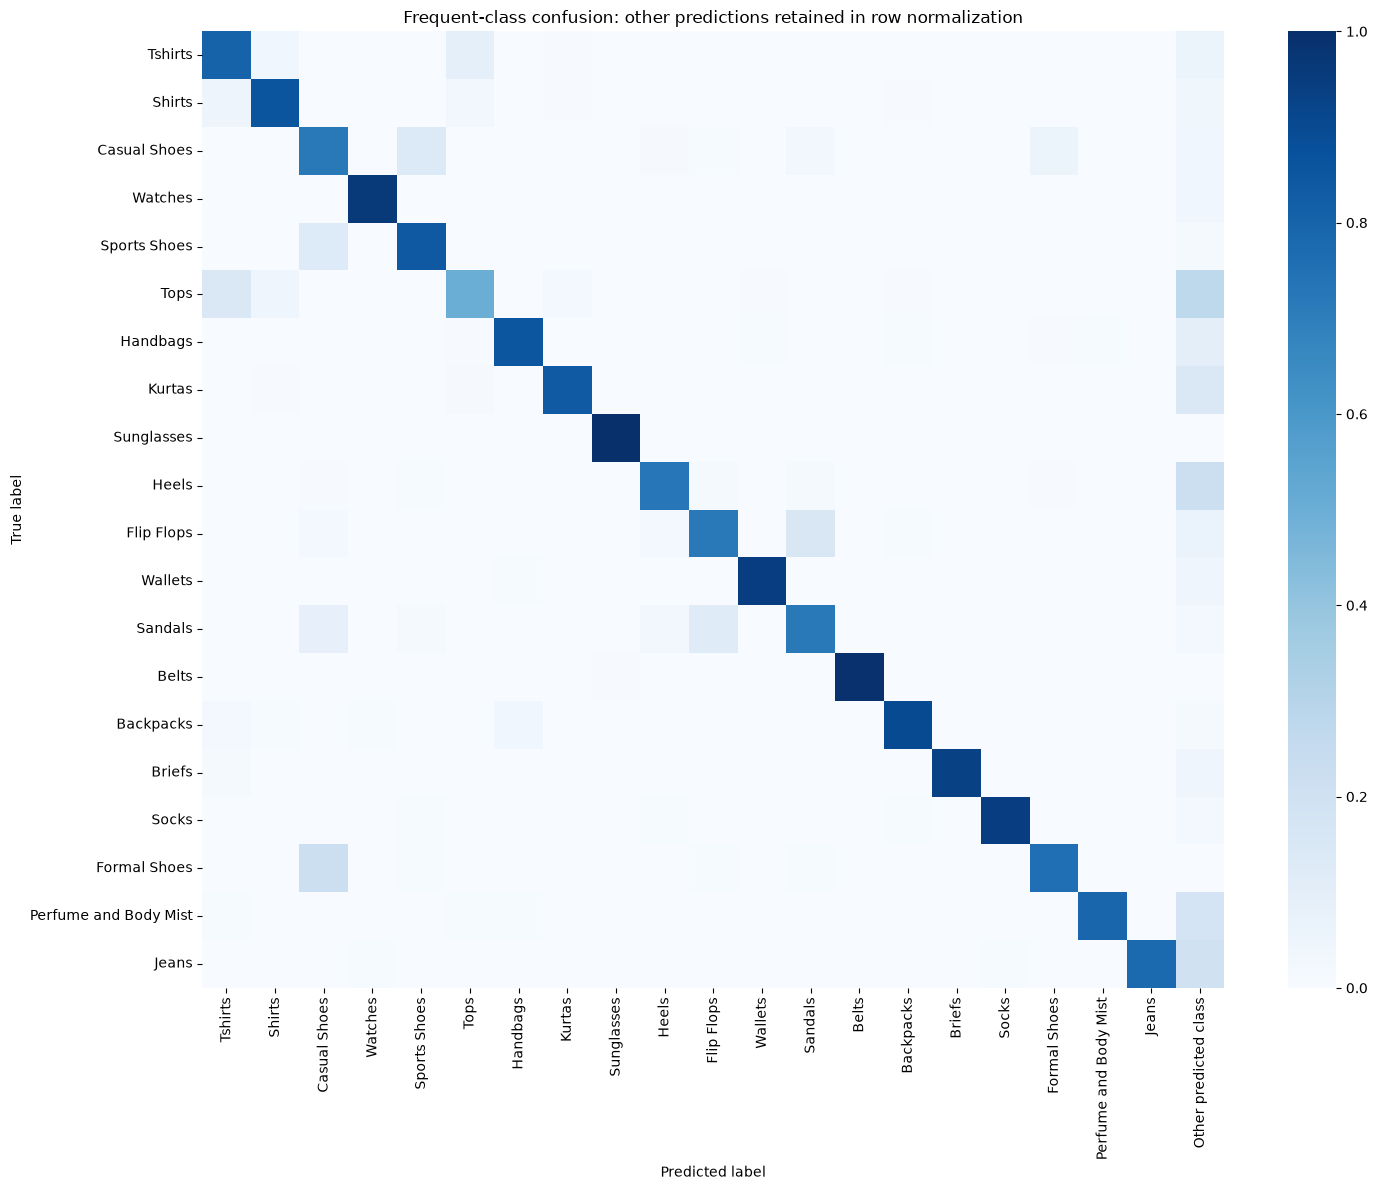

In [14]:
from sklearn.metrics import confusion_matrix
largest_labels = counts.head(20).index.tolist()
largest_indices = [label_to_index[label] for label in largest_labels]
other_indices = [i for i in range(len(labels)) if i not in largest_indices]
full_confusion = confusion_matrix(test_truth, test_predictions, labels=np.arange(len(labels)))
selected_rows = full_confusion[largest_indices]
displayed_confusion = np.column_stack([
    selected_rows[:, largest_indices], selected_rows[:, other_indices].sum(axis=1),
]).astype(float)
displayed_confusion /= selected_rows.sum(axis=1, keepdims=True)
assert np.allclose(displayed_confusion.sum(axis=1), 1.0)
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(displayed_confusion, xticklabels=largest_labels + ['Other predicted class'],
            yticklabels=largest_labels, cmap='Blues', vmin=0, vmax=1, ax=ax)
ax.set(xlabel='Predicted label', ylabel='True label',
       title='Frequent-class confusion: other predictions retained in row normalization')
plt.tight_layout()
plt.show()

### 10.1 Failure analysis

Full CPU test accuracy is 0.7782, supported-label macro F1 0.6114, and ECE 0.1221. The selected HOG+HSV pipeline runs on CPU. Separate CPU verification reproduces the saved checkpoint metrics; exact differences are retained in the verification record.

The weakest supported labels include Basketballs (F1 0.000, n=1), Blazers (F1 0.000, n=3), Bracelet (F1 0.000, n=1). Small class counts make these estimates noisy. The class and subgroup tables describe errors; they do not establish which visual cues caused them.

On the same fixed 300-image robustness sample, macro F1 is: clean 0.6519, brightness_0.8 0.6086, brightness_1.2 0.5585, gaussian_blur_0.7 0.6174. These are sample scores, not full-test scores. The selected checkpoint occupies 0.97 MiB. CPU timing is machine-dependent and includes image preprocessing; it is not an end-to-end web benchmark.

Top-3 accuracy is 0.9419. Support bands: tail (<50): F1 0.5061, 176 images; medium (50-499): F1 0.6696, 1586 images; head (>=500): F1 0.8220, 3956 images. Band scores average per-class F1 computed on the complete partition, retaining cross-band false positives.


The head-to-tail gap is about 0.316 macro F1 (0.8220 minus 0.5061), so good
overall accuracy does not imply reliable coverage of rare article types. The
high-confidence error table includes Kurtis -> Kurtas (ID 30881), Boxers -> Trunk
(28105), and Handbags -> Laptop Bag (42844). These are concrete confusion
examples; the table alone cannot prove which shape or colour cues caused them.

Calibration also limits how confidence should be interpreted: in the 0.9-1.0
bin, mean confidence is 0.9859 but accuracy is 0.8887 (4,071 examples). The
selected model is overconfident despite winning macro F1. Its 20%-brightened
sample loses about 0.093 macro F1 relative to the same clean sample. A future
validation-only calibration or lighting experiment could investigate this, but
neither has been performed and no corrected confidence is claimed.

## 11. Save the Selected Model

In [15]:
checkpoint_path = ROOT / 'models' / 'article_type_model.pt'
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
validation_metrics = {key: float(comparison.loc[SELECTED_METHOD, key]) for key in ('validation_accuracy', 'validation_macro_f1', 'validation_ece')}
if SELECTED_MODEL_TYPE == 'simple_cnn':
    checkpoint = {
        'model_type': 'simple_cnn', 'target': TARGET, 'labels': labels,
        'state_dict': model.cpu().state_dict(), 'mean': normalisation['mean'], 'std': normalisation['std'],
        'image_size': list(IMAGE_SIZE), 'dropout': 0.2, 'loss_mode': SELECTED_LOSS_MODE,
    }
else:
    checkpoint = {
        'model_type': 'hog_hsv_logistic_regression', 'target': TARGET, 'labels': labels,
        'estimator': model, 'feature_config': DEFAULT_FEATURE_CONFIG,
    }
checkpoint.update({'selection_metric': 'validation_macro_f1', 'best_validation_macro_f1': best_f1, 'validation_metrics': validation_metrics, 'test_metrics': test_metrics, 'seed': SEED})
checkpoint['experiment'] = 'simple_cnn_v1'
torch.save(checkpoint, checkpoint_path)
cpu_predictor = FashionClassifier(checkpoint_path, device='cpu')
robustness = saved_model_robustness(cpu_predictor, test_df, TARGET, SEED)
display(robustness)
print(f'Checkpoint size: {checkpoint_path.stat().st_size / 1024**2:.2f} MiB')
history.to_csv(ROOT / 'models' / 'article_type_history.csv', index=False)
comparison.to_csv(ROOT / 'models' / 'article_type_comparison.csv')
checkpoint_path

,samples,accuracy,macro_f1,mean_confidence,milliseconds_per_image
variant,,,,,
clean,300,0.776667,0.651892,0.897513,1.393413
brightness_0.8,300,0.713333,0.608650,0.891748,1.423331
brightness_1.2,300,0.736667,0.558542,0.892371,1.371700
gaussian_blur_0.7,300,0.770000,0.617359,0.898953,1.467918


Checkpoint size: 0.97 MiB


WindowsPath('D:/khoile/programs/fashion-intelligence-classification/models/article_type_model.pt')

## 12. Final Prediction Check

In [16]:
with Image.open(validation_df.image_path.iloc[0]) as image:
    print(FashionClassifier(ROOT / 'models' / 'article_type_model.pt', device='cpu').predict(image))

{'target': 'articleType', 'label': 'Sports Shoes', 'confidence': 0.8313984870910645, 'top_k': [{'label': 'Sports Shoes', 'confidence': 0.8313984870910645}, {'label': 'Casual Shoes', 'confidence': 0.16859278082847595}, {'label': 'Sandals', 'confidence': 6.887202289362904e-06}]}


## 13. Ultimate judgement

The selected hog_hsv_logistic_regression reaches validation macro F1 0.6096, compared with 0.6089 for the previous selected model (change +0.0007). The simplified experiment uses one ordinary-loss plain CNN and a classical baseline per target. It removes the residual architecture and loss-mode search from current training. The same settings were used for every target; this combined change does not isolate a causal improvement. Use it for catalogue tagging with the reported rare-class and confidence limitations. The previously inspected internal test is a follow-up evaluation, not evidence from an untouched holdout.

## 14. Independent literature comparison

Ziwei Liu, Ping Luo, Shi Qiu, Xiaogang Wang and Xiaoou Tang (2016). [DeepFashion: Powering Robust Clothes Recognition and Retrieval with Rich Annotations](https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/Liu_DeepFashion_Powering_Robust_CVPR_2016_paper.pdf). *CVPR*, pp. 1096–1104.

DeepFashion addresses the related goal of clothing category recognition. FashionNet combines global features with clothing landmarks and attribute supervision. The paper reports 82.58% category top-3 accuracy (Table 2). Its 50-category benchmark, additional supervision, large-scale pretraining/fine-tuning protocol and shop/consumer imagery differ from our 124-category private catalogue, frozen product-group split and models trained only on the supplied training rows. Our measured top-3 accuracy therefore does not establish superiority; neither top-3 score is directly comparable to our primary macro F1. The methodological lesson is that localized garment information can help recognition, while our experiment only establishes the relative performance of the three candidates on this dataset. No paper weights or images were imported.

## 15. Lighting and confidence follow-up

The following results come from the separately executed fixed-protocol experiment; original code/output cells above are retained verbatim as historical evidence. No dataset files were changed.

| Target | Old accuracy | New accuracy | Old F1 | New F1 | Old ECE | New ECE |
|---|---:|---:|---:|---:|---:|---:|
| articleType | 0.7782 | 0.7782 | 0.6114 | 0.6114 | 0.1221 | 0.0111 |
| season | 0.6952 | 0.6952 | 0.6827 | 0.6827 | 0.0218 | 0.0218 |
| gender | 0.8538 | 0.8538 | 0.6725 | 0.6725 | 0.0248 | 0.0248 |
| usage | 0.7705 | 0.7705 | 0.3639 | 0.3639 | 0.0984 | 0.0303 |

| Target | Temperature | Review threshold | Test coverage | Accepted test accuracy |
|---|---:|---:|---:|---:|
| articleType | 2.072 | 0.62 | 73.70% | 88.56% |
| season | 1.000 | 0.72 | 45.67% | 88.24% |
| gender | 1.000 | 0.52 | 93.51% | 88.65% |
| usage | 1.819 | 0.83 | 42.39% | 89.11% |

ECE and selective accuracy measure different things from overall accuracy. The 90% acceptance target was chosen on validation, not guaranteed on test. See the root change record for lighting comparisons, separate validation views and limitations.

## 16. Further classifier trials (from scratch)

| Target | Selected | Accuracy before / after | Macro F1 before / after | ECE before / after |
|---|---|---:|---:|---:|
| articleType | active_baseline | 77.82% / 77.82% | 0.6114 / 0.6114 | 0.0111 / 0.0111 |
| season | cnn_control_s2753 | 69.52% / 71.29% | 0.6827 / 0.6934 | 0.0218 / 0.0282 |
| gender | active_baseline | 85.38% / 85.38% | 0.6725 / 0.6725 | 0.0248 / 0.0248 |
| usage | hog_c0.1_sqrt | 77.05% / 84.42% | 0.3639 / 0.4134 | 0.0303 / 0.0191 |

These are separately executed follow-up results. See [CLASSIFIER_TRIALS.md](../CLASSIFIER_TRIALS.md) for all candidates, validation selection, uncertainty, and limitations. The code and outputs above remain historical; rerunning their export cells overwrites the active checkpoints. No original dataset files were changed; no pretrained model was used.

## 17. Accuracy-priority update

| Target | Accuracy before / after | Macro F1 before / after | ECE before / after |
|---|---:|---:|---:|
| articleType | 77.82% / 80.12% | 0.6114 / 0.6241 | 0.0111 / 0.0105 |
| gender | 85.38% / 87.25% | 0.6725 / 0.6704 | 0.0248 / 0.0196 |

These active checkpoints supersede the earlier strict-ECE selection. See [CLASSIFIER_TRIALS.md](../CLASSIFIER_TRIALS.md#accuracy-priority-update) for the user-selected trade-off and test limitations. Earlier code/output cells are historical; rerunning exports overwrites these checkpoints.

## 18. Lighting-instability review check

Brightness-averaged classification was rejected because validation accuracy declined. An additional article-type review flag detects disagreement at brightness 0.8/1.0/1.2. It catches 143 additional test errors but flags 341 additional correct predictions. Labels, probabilities and overall classifier metrics remain unchanged. The original browser T-shirt error is now flagged; the darkened version remains unflagged and wrong. See [CLASSIFIER_ROBUSTNESS.md](../CLASSIFIER_ROBUSTNESS.md).

## 19. Simple training follow-up

| Target | Candidate | Accuracy | Macro F1 | Policy ECE | Adopted |
|---|---|---:|---:|---:|---|
| articleType | active | 80.93% | 0.6206 | 0.0154 | False |
| articleType | brightness_training | 81.34% | 0.6226 | 0.0192 | True |
| articleType | normalized_c0.1 | 46.31% | 0.1051 | 0.0836 | False |
| articleType | normalized_c1 | 70.03% | 0.2592 | 0.0351 | False |
| articleType | normalized_c10 | 78.62% | 0.5768 | 0.0235 | False |
| season | active | 72.98% | 0.7164 | 0.0211 | False |
| season | mild_brightness | 72.37% | 0.7096 | 0.0369 | False |
| season | scheduler_control | 71.76% | 0.7026 | 0.0219 | False |
| gender | active | 87.93% | 0.7337 | 0.0136 | False |
| gender | mild_brightness | 87.55% | 0.7340 | 0.0130 | False |
| gender | scheduler_control | 87.93% | 0.7337 | 0.0137 | False |

Choices were frozen before any candidate test evaluation. Neither labels nor individual browser examples influenced selection. The source dataset was not changed.

Selected replacements: {'articleType': 'brightness_training', 'season': None, 'gender': None}.

articleType: test before {'accuracy': 0.8011542497376705, 'macro_f1': 0.6240876563644999, 'ece': 0.010474646054413297, 'nll': 0.6333052775405534, 'brier': 0.27773200824621913}; after {'accuracy': 0.8027282266526757, 'macro_f1': 0.6301964376461315, 'ece': 0.01597138658457, 'nll': 0.6258464439445816, 'brier': 0.2754707893915741}; group-bootstrap intervals {'accuracy': [-0.0024303080753702634, 0.005705075709133136], 'macro_f1': [-0.00747004311592406, 0.021074159787583407], 'ece': [-0.005533713043723776, 0.010846000725079432]}.

The normalized article grid changes both feature geometry and effective regularization. Its failure would not prove that all possible shape-weighted models fail. The grid was not expanded after viewing results. CNN control and augmentation share the architecture, scheduler, seed and stopping split; only training brightness differs. No pretrained weights, test-driven tuning or catalogue-label substitution.

Temporary scripts and comparison CSV were removed at the user?s request. Trial caches remain because automatic approval review blocked recursive deletion. The measured results above and SIMPLE_TRAINING_TRIALS.md are retained. Validation/test partitions have prior development exposure.

See [SIMPLE_TRAINING_TRIALS.md](../SIMPLE_TRAINING_TRIALS.md).

Browser follow-up: the T-shirt and shoe examples remain misclassified; the modest aggregate improvement is not a fix for those specific errors. See the linked change record for the updated review behavior and uncertain bootstrap intervals.